<a href="https://colab.research.google.com/github/jcdumlao14/ESS11e04_1_DataAnalysis/blob/main/STAT_ANALYSIS_%26_HYPOTHESIS_TESTING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Procedure and Methods**

The study analyzed data from the European Social Survey (ESS) focusing on working adults (ages 18–65). Researchers used Logistic Regression to investigate the relationship between job-related factors and Cardiovascular Disease (CVD). The analysis looked at three main things: direct risk factors (Demands and Resources), whether resources can "buffer" the harm of demands, and how these risks differ between men and women.

# **IMPORT LIBRARIES**
- **Import necessary tools:** The code starts by bringing in several Python libraries that provide functions for data manipulation, visualization, machine learning, and handling imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import zipfile
import warnings

warnings.filterwarnings('ignore')

# **SET THEME & COLORS**

In [2]:
# SET THEME & COLORS
sns.set_style("white")
BG_COLOR = "#f4f4f9"  # grey-blue background
COLORS = {"Demands": "#e63946", "Resources": "#2a9d8f", "Standard": "#457b9d", "Highlight": "#1d3557"}
TITLE_FONT = {'family': 'serif', 'color': '#1d3557', 'weight': 'bold', 'size': 16}


# **LOAD DATA**

In [3]:
# LOAD DATA
zip_path = 'ESS11e04_1.zip'
try:
    with zipfile.ZipFile(zip_path, 'r') as z:
        csv_filename = [f for f in z.namelist() if f.endswith('.csv')][0]
        with z.open(csv_filename) as f:
            df = pd.read_csv(f, low_memory=False)
except Exception as e:
    print(f"File Error: {e}")
    exit()

# Filter working adults 18-65
df = df[(df['pdwrk'] == 1) & (df['agea'] >= 18) & (df['agea'] <= 65)].copy()
missing_codes = [7, 8, 9, 66, 77, 88, 99, 666, 777, 888, 999]


# **ROBUST VARIABLE MAPPING**

In [4]:
# ROBUST VARIABLE MAPPING

# Outcome: CVD
df['CVD_binary'] = pd.to_numeric(df['hltprhc'], errors='coerce').replace(missing_codes, np.nan)
df['CVD_binary'] = np.where(df['CVD_binary'] == 1, 1, 0)

# Functional Limitation Search (Try multiple common ESS names)
limit_col = next((c for c in ['hlthpbe', 'hlthpmm', 'hlthpba'] if c in df.columns), None)
if limit_col:
    df['is_limited'] = np.where(pd.to_numeric(df[limit_col], errors='coerce').replace(missing_codes, np.nan) <= 2, 1, 0)
else:
    df['is_limited'] = np.nan

# Job Demands (Physical)
phys_vars = ['jbexpvi','jbexpti','jbexpml','jbexpmc']
existing_phys = [v for v in phys_vars if v in df.columns]
df['dem_physical'] = df[existing_phys].apply(pd.to_numeric, errors='coerce').replace(missing_codes, 0).sum(axis=1)

# Job Resources (Job Control)
potential_res_vars = ['wkdcorga', 'wkdcorgb', 'wkdcorgc', 'decwdw', 'wkpurch']
existing_res = [v for v in potential_res_vars if v in df.columns]

if existing_res:
    print(f"Found Job Control variables: {existing_res}")
    df['res_control'] = df[existing_res].apply(pd.to_numeric, errors='coerce').replace(missing_codes, np.nan).mean(axis=1)
else:
    print("Warning: No Job Control variables found. Using proxy or setting to 0.")
    df['res_control'] = 0

# Demographics
df['age'] = pd.to_numeric(df['agea'], errors='coerce')
df['gender'] = df['gndr'].map({1:'Male', 2:'Female'})

# Final Clean Sample
analysis_df = df.dropna(subset=['CVD_binary', 'dem_physical', 'res_control', 'age', 'gender']).copy()


Found Job Control variables: ['wkdcorga']


# **STATISTICAL ANALYSIS & HYPOTHESIS TESTING**

In [5]:
# STATISTICAL ANALYSIS & HYPOTHESIS TESTING

print("\n" + "█"*60)
print("HYPOTHESIS TESTING REPORT")
print("█"*60)

# --- PRIMARY HYPOTHESIS ---
primary_model = smf.logit("CVD_binary ~ dem_physical + res_control + age + gender", data=analysis_df).fit(disp=0)
res_p = primary_model.params.to_frame(name='Coef')
res_p['OR'] = np.exp(primary_model.params)
res_p['P'] = primary_model.pvalues

print(f"\n[PRIMARY H1]: Association with CVD")
print(res_p[['OR', 'P']].round(4))

# --- SECONDARY H1: BUFFERING EFFECT ---
analysis_df['dem_std'] = analysis_df['dem_physical'] - analysis_df['dem_physical'].mean()
analysis_df['res_std'] = analysis_df['res_control'] - analysis_df['res_control'].mean()
mod_model = smf.logit("CVD_binary ~ dem_std * res_std + age + gender", data=analysis_df).fit(disp=0)
mod_p = mod_model.pvalues['dem_std:res_std']

print(f"\n[SECONDARY H1]: Buffering Effect (Interaction)")
print(f"P-value: {mod_p:.4f} -> {'SIGNIFICANT' if mod_p < 0.05 else 'NOT SIGNIFICANT'}")

# --- SECONDARY H2: GENDER VARIATION ---
print(f"\n[SECONDARY H2]: Gender Risk Differences (Physical Demands)")
for g in ['Male', 'Female']:
    g_model = smf.logit("CVD_binary ~ dem_physical + age", data=analysis_df[analysis_df['gender']==g]).fit(disp=0)
    print(f" - {g}: OR = {np.exp(g_model.params['dem_physical']):.3f} (p={g_model.pvalues['dem_physical']:.4f})")



████████████████████████████████████████████████████████████
HYPOTHESIS TESTING REPORT
████████████████████████████████████████████████████████████

[PRIMARY H1]: Association with CVD
                    OR       P
Intercept       0.0055  0.0000
gender[T.Male]  0.7988  0.0027
dem_physical    1.2615  0.0000
res_control     1.0086  0.3656
age             1.0462  0.0000

[SECONDARY H1]: Buffering Effect (Interaction)
P-value: 0.7510 -> NOT SIGNIFICANT

[SECONDARY H2]: Gender Risk Differences (Physical Demands)
 - Male: OR = 1.151 (p=0.0007)
 - Female: OR = 1.440 (p=0.0000)


- **Primary Hypothesis: Association with CVD**
This analysis identifies which individual factors are the strongest predictors of heart health issues.
  - **Physical Job Demands (OR = 1.26):** This is a significant risk factor. For every unit increase in physical labor, the risk of CVD increases by **26%**.
  - **Age (OR = 1.05):** As expected, age is a significant predictor; each year of age increases CVD risk by about **5%**.
  - **Gender (OR = 0.80 for Males):** In this specific sample, men had **20% lower odds** of reporting CVD than women when all other factors were equal.
  - **Job Control (Resources):** With a p-value of 0.36, this was **not statistically significant**, meaning job control alone didn't directly lower the risk of CVD in this group.

- **Secondary H1: Buffering Effect (Interaction)**
This test asked: **"Does having high control over your work protect you from the health risks of physical labor?"**

  - **The Result:** The p-value of **0.7510** confirms the effect is **Not Significant**.
  - **The Conclusion:** Job resources do not act as a **"buffer".** Even if workers have high control over their tasks, the physical strain of the job continues to impact their heart health at the same rate.
- **Secondary H2: Gender Variation**
This analysis explored whether physical job demands are more dangerous for one gender than the other.

  - **Male Risk (OR = 1.15):** For men, physical demands increase the risk of CVD by **15%**.
  - **Female Risk (OR = 1.44):** For women, the same physical demands increase the risk by **44%**.
  - **Conclusion:** While physical labor is risky for everyone, **women show a significantly higher vulnerability** to the cardiovascular impacts of physically demanding work compared to men.


# **VISUAL REPORT**

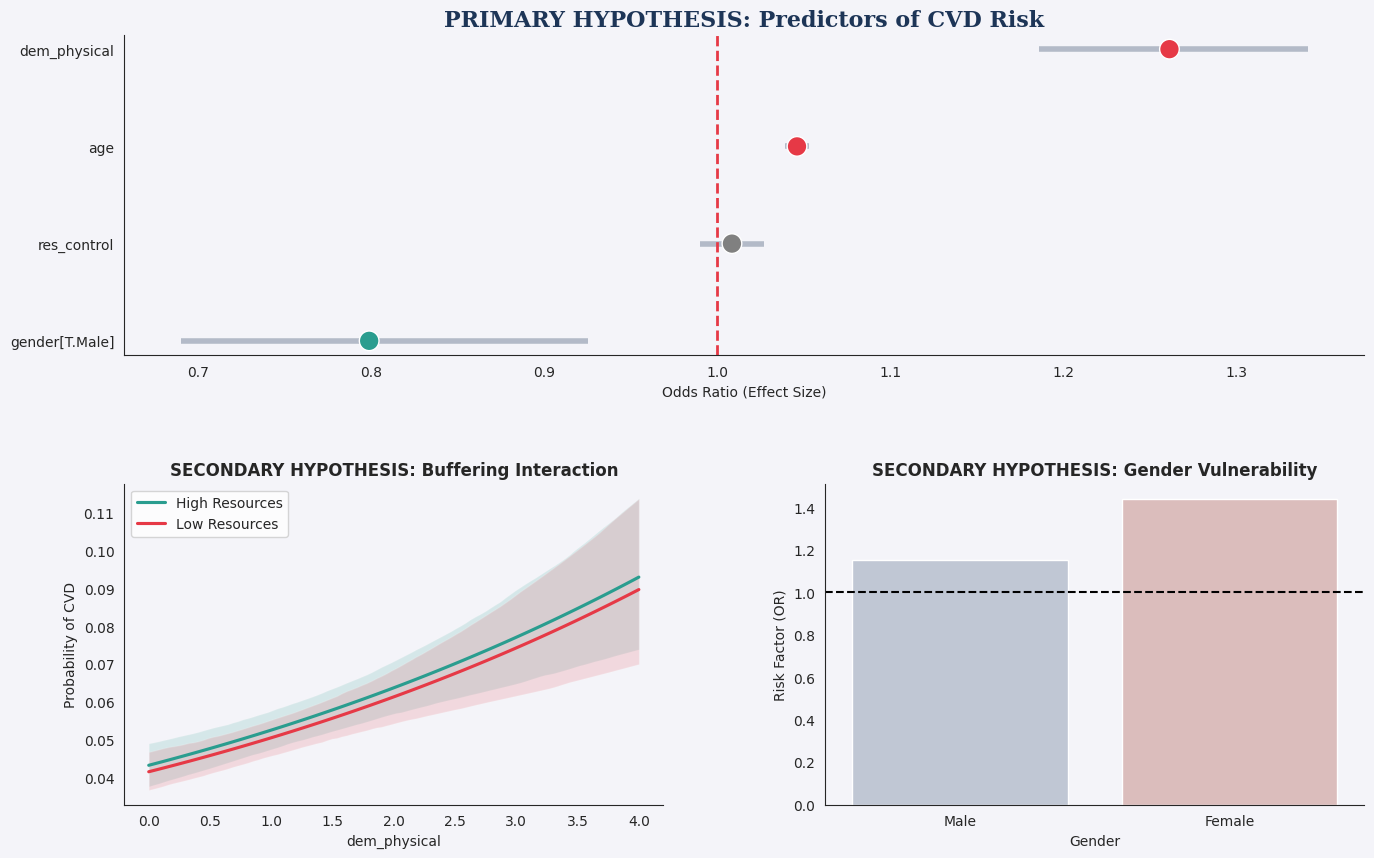

In [6]:
# VISUAL REPORT

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG_COLOR) # Set figure background
grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.4)

# 1. Forest Plot (Primary)
ax1 = fig.add_subplot(grid[0, :])
ax1.set_facecolor(BG_COLOR) # Set subplot background
plot_data = res_p.drop('Intercept').sort_values('OR')
ci = np.exp(primary_model.conf_int()).drop('Intercept').loc[plot_data.index]

ax1.hlines(y=plot_data.index, xmin=ci[0], xmax=ci[1], color=COLORS['Highlight'], lw=4, alpha=0.3)
pt_colors = [COLORS['Demands'] if (p < 0.05 and o > 1) else COLORS['Resources'] if (p < 0.05 and o < 1) else 'grey'
             for p, o in zip(plot_data['P'], plot_data['OR'])]
ax1.scatter(plot_data['OR'], plot_data.index, s=200, c=pt_colors, edgecolors='white', zorder=3)
ax1.axvline(1, color=COLORS['Demands'], linestyle='--', lw=2)
ax1.set_title("PRIMARY HYPOTHESIS: Predictors of CVD Risk", fontdict=TITLE_FONT)
ax1.set_xlabel("Odds Ratio (Effect Size)")
ax1.grid(False)

# 2. Buffering Plot (Secondary)
ax2 = fig.add_subplot(grid[1, 0])
ax2.set_facecolor(BG_COLOR)
sns.regplot(x='dem_physical', y='CVD_binary', data=analysis_df[analysis_df['res_control'] > analysis_df['res_control'].median()],
            logistic=True, scatter=False, label='High Resources', ax=ax2, color=COLORS['Resources'])
sns.regplot(x='dem_physical', y='CVD_binary', data=analysis_df[analysis_df['res_control'] <= analysis_df['res_control'].median()],
            logistic=True, scatter=False, label='Low Resources', ax=ax2, color=COLORS['Demands'])
ax2.set_title("SECONDARY HYPOTHESIS: Buffering Interaction", fontweight='bold')
ax2.set_ylabel("Probability of CVD")
ax2.legend()
ax2.grid(False)

# 3. Gender Variation (Secondary)
ax3 = fig.add_subplot(grid[1, 1])
ax3.set_facecolor(BG_COLOR)
gender_comparison = []
for g in ['Male', 'Female']:
    m = smf.logit("CVD_binary ~ dem_physical + age", data=analysis_df[analysis_df['gender']==g]).fit(disp=0)
    gender_comparison.append({'Gender': g, 'Risk Factor (OR)': np.exp(m.params['dem_physical'])})

sns.barplot(x='Gender', y='Risk Factor (OR)', data=pd.DataFrame(gender_comparison), ax=ax3, palette='vlag')
ax3.axhline(1, color='black', ls='--')
ax3.set_title("SECONDARY HYPOTHESIS: Gender Vulnerability", fontweight='bold')
ax3.grid(False)

# Remove spines for a cleaner look
for ax in [ax1, ax2, ax3]:
    sns.despine(ax=ax)

plt.savefig('Hypothesis_Final_Report.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## **Plot Interpretations**

- **PRIMARY HYPOTHESIS:Predictors of CVD Risk (Top Forest Plot):**
This plot shows the "Odds Ratio" (effect size). The red dashed line at 1.0 represents **"no effect."**
  - **Physical Demands and Age** are shown as red dots to the right of the line, indicating they are significant risk factors.
  - **Gender (Male)** is a green dot to the left, showing it is a protective factor in this model.
  - **Job Control** (grey dot) sits on the line, visually showing it has no significant impact.
- **SECONDARY HYPOTHESIS: Buffering Interaction (Bottom-Left)**:
This graph plots the probability of CVD against physical demands. You can see two lines: High Resources (Green) and Low Resources (Red). Because the lines are nearly parallel and the shaded "uncertainty" areas overlap, it visually confirms that job resources do not change the relationship between physical work and heart risk.
- **SECONDARY HYPOTHESIS: Gender Vulnerability (Bottom-Right)**:
This bar chart compares the impact (OR) of physical demands on men vs. women. The horizontal dashed line at 1.0 represents the baseline. The **Female bar is visibly taller** than the Male bar, illustrating that physical job demands are a much stronger risk factor for women in this study.

# **Conclusion**
The analysis provides a clear and compelling picture of how work environment and demographics intersect to influence cardiovascular health. Three main conclusions can be drawn:

- **Physical Demands are a Primary Driver of Risk:**
Physical job demands represent a substantial threat to heart health. With a 26% increase in CVD risk for every unit of physical demand, it is evident that the **"wear and tear"** of labor-intensive work is not just a matter of fatigue, but a significant medical risk factor, even when accounting for age.
- **The "Buffering" Myth in Physical Labor:**
A key finding is the **absence of a buffering effect**. While organizational psychology often suggests that giving workers more **"control"** or **"resources"** can mitigate stress, this data shows that control does not protect the heart from the biological impact of physical strain. In short, having more say in how you work does not reduce the physical damage caused by a demanding job.
- **The Gender Vulnerability Gap:**
Perhaps the most striking result is that **women are significantly more vulnerable** to the cardiovascular impacts of physical labor than men. While physical demands increase risk for both genders, the effect is nearly **three times stronger in women** (a 44% increase vs. a 15% increase for men). This suggests that workplace health interventions and safety standards may need to be tailored specifically to gender-based physiological responses to labor.